<a href="https://colab.research.google.com/github/simondiange/simondiange/blob/main/Prediction_model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install pyforest

  Preparing metadata (setup.py) ... done
  Created wheel for pyforest: filename=pyforest-1.1.2-py2.py3-none-any.whl size=15902 sha256=c48316906096d08c5206b8180b4b191b13d64363c332dcc637184a50249786ca
  Stored in directory: /root/.cache/pip/wheels/66/4f/3c/cbdf5336b5a84f39cb6e3d76eecb9acf3f99a2c072785afecc
Successfully built pyforest


In [ ]:
from pyforest import *
lazy_imports()

['import dash',
 'import tqdm',
 'import spacy',
 'from sklearn import metrics',
 'import plotly as py',
 'from sklearn.model_selection import KFold',
 'import torch',
 'from sklearn.linear_model import LinearRegression',
 'import plotly.express as px',
 'from sklearn.decomposition import PCA',
 'import matplotlib.pyplot as plt',
 'import statistics',
 'from fbprophet import Prophet',
 'import nltk',
 'import sys',
 'from sklearn.preprocessing import MinMaxScaler',
 'import altair as alt',
 'from sklearn.cluster import KMeans',
 'import numpy as np',
 'from sklearn.preprocessing import RobustScaler',
 'import gensim',
 'from scipy import stats',
 'import re',
 'from sklearn.feature_extraction.text import CountVectorizer',
 'import datetime as dt',
 'import glob',
 'from sklearn.manifold import TSNE',
 'from sklearn.linear_model import LogisticRegression',
 'import statsmodels.api as sm',
 'from sklearn.linear_model import ElasticNetCV',
 'from sklearn.impute import SimpleImputer',
 'fr

In [ ]:
from pyforest import *
lazy_imports()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [ ]:
df = pd.read_csv('BankNote_Authentication.csv')
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.info

<bound method DataFrame.info of       variance  skewness  curtosis  entropy  class
0      3.62160   8.66610   -2.8073 -0.44699      0
1      4.54590   8.16740   -2.4586 -1.46210      0
2      3.86600  -2.63830    1.9242  0.10645      0
3      3.45660   9.52280   -4.0112 -3.59440      0
4      0.32924  -4.45520    4.5718 -0.98880      0
...        ...       ...       ...      ...    ...
1367   0.40614   1.34920   -1.4501 -0.55949      1
1368  -1.38870  -4.87730    6.4774  0.34179      1
1369  -3.75030 -13.45860   17.5932 -2.77710      1
1370  -3.56370  -8.38270   12.3930 -1.28230      1
1371  -2.54190  -0.65804    2.6842  1.19520      1

[1372 rows x 5 columns]>

In [ ]:
df.dtypes

,0
variance,float64
skewness,float64
curtosis,float64
entropy,float64
class,int64


In [ ]:
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
df.isna().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


In [ ]:
print(df['class'].value_counts())

class
0    762
1    610
Name: count, dtype: int64


In [ ]:
X=df.head(10)
print(X)

   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661  -2.80730 -0.44699      0
1   4.54590    8.1674  -2.45860 -1.46210      0
2   3.86600   -2.6383   1.92420  0.10645      0
3   3.45660    9.5228  -4.01120 -3.59440      0
4   0.32924   -4.4552   4.57180 -0.98880      0
5   4.36840    9.6718  -3.96060 -3.16250      0
6   3.59120    3.0129   0.72888  0.56421      0
7   2.09220   -6.8100   8.46360 -0.60216      0
8   3.20320    5.7588  -0.75345 -0.61251      0
9   1.53560    9.1772  -2.27180 -0.73535      0


In [ ]:
# Reload the dataset to ensure 'class' column is present
df = pd.read_csv('BankNote_Authentication.csv')

# Separate features (X) and target variable (y)
X = df.drop('class', axis=1)
y = df['class']

display(X.head())
display(y.head())

,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


,class
0,0
1,0
2,0
3,0
4,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

display(X[:5]) # Display the first 5 rows of the scaled features

array([[ 1.12180565,  1.14945512, -0.97597007,  0.35456135],
       [ 1.44706568,  1.06445293, -0.89503626, -0.12876744],
       [ 1.20780971, -0.77735215,  0.12221838,  0.61807317],
       [ 1.06374236,  1.29547754, -1.25539712, -1.14402883],
       [-0.03677175, -1.0870383 ,  0.73673042,  0.09658697]])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (960, 4)
Shape of X_test: (412, 4)
Shape of y_train: (960,)
Shape of y_test: (412,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the model: {accuracy}")

Accuracy of the model: 0.9975728155339806


<Figure size 400x300 with 0 Axes>

<Axes: >

Text(0.5, 3.722222222222216, 'Predicted')

Text(20.72222222222222, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix')

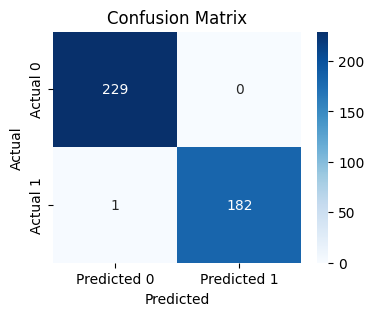

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()